In [1]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
import torch.optim as optim

import torchvision
from torchvision.transforms import transforms
from torchvision.datasets import CIFAR10

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Transforms
train_transform = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

In [3]:
# Load Datasets
full_datasets = CIFAR10(root="./data", train=True, download=True)

In [4]:
# Train dataset (with augmentation)
train_dataset_full = CIFAR10(root="./data", train=True, download=False, transform=train_transform)

# Validation dataset (NO augmentation)
val_dataset_full = CIFAR10(root="./data", train=True, download=False, transform=test_transform)

# Test dataset (separate official test set)
test_dataset = CIFAR10(root="./data", train=False, download=True, transform=test_transform)

In [5]:
# Split Datasets_Size into train and validation 
dataset_size = len(full_datasets)
split = int(0.8 * dataset_size)

indices = torch.randperm(dataset_size)
train_indices = indices[:split]
val_indices = indices[split:]

In [6]:
# Split Datasets into train, Validation
train_dataset = Subset(train_dataset_full, train_indices)
val_dataset   = Subset(val_dataset_full, val_indices)

In [7]:
# Load data in Train, validation, test
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [8]:
# CNN Model

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(2*2*256, 256),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(256, 10),
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        
        return x

In [9]:
model = CNN()

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

best_val_loss = float("inf")
train_losses = []
val_losses = []

epochs = 20

for epoch in range(epochs):
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0
########## Train ###############
    for image, label in (train_loader):
        image = image.to(device)
        label = label.to(device)

        optimizer.zero_grad()

        output = model(image)
        loss = criterion(output, label)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * image.size(0)

        _, prediction = torch.max(output, 1)
        train_correct += (prediction == label).sum().item()
        train_total += label.size(0)
        
    epoch_train_loss = train_loss / train_total
    train_acc = (train_correct / train_total) * 100
    train_losses.append(epoch_train_loss)

########### Validation #############
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for image, label in (val_loader):
            image = image.to(device)
            label = label.to(device)
            
            output = model(image)
            loss = criterion(output, label)

            val_loss += loss.item() * image.size(0)
    
            _, preds = torch.max(output, 1)
            val_correct += (preds == label).sum().item()
            val_total += label.size(0)
            
    epoch_val_loss = val_loss / val_total
    val_acc = (val_correct / val_total) * 100
    val_losses.append(epoch_val_loss)

    print(f"""
    Epoch {epoch+1} / {epochs}
    Train Loss: {epoch_train_loss:.4f} | Train Acc: {train_acc:.4f}
    Val   Loss: {epoch_val_loss:.4f} | Val   Acc: {val_acc:.4f}
    """)  

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "cifar10_final.pt")


    Epoch 1 / 20
    Train Loss: 1.4366 | Train Acc: 47.7775
    Val   Loss: 1.1005 | Val   Acc: 59.9500
    

    Epoch 2 / 20
    Train Loss: 1.0743 | Train Acc: 61.8650
    Val   Loss: 0.9069 | Val   Acc: 68.0100
    

    Epoch 3 / 20
    Train Loss: 0.9294 | Train Acc: 67.6475
    Val   Loss: 0.8077 | Val   Acc: 71.8100
    

    Epoch 4 / 20
    Train Loss: 0.8376 | Train Acc: 70.8275
    Val   Loss: 0.8088 | Val   Acc: 71.6000
    

    Epoch 5 / 20
    Train Loss: 0.7717 | Train Acc: 73.3275
    Val   Loss: 0.6865 | Val   Acc: 75.9700
    

    Epoch 6 / 20
    Train Loss: 0.7280 | Train Acc: 74.9400
    Val   Loss: 0.6528 | Val   Acc: 77.3900
    

    Epoch 7 / 20
    Train Loss: 0.6829 | Train Acc: 76.3525
    Val   Loss: 0.6178 | Val   Acc: 78.4600
    

    Epoch 8 / 20
    Train Loss: 0.6507 | Train Acc: 77.7700
    Val   Loss: 0.6507 | Val   Acc: 77.2900
    

    Epoch 9 / 20
    Train Loss: 0.6162 | Train Acc: 78.8575
    Val   Loss: 0.5845 | Val   Acc: 79.5300
    



In [12]:
############# Test ###########

model.eval()
correct = 0
total = 0

all_pred = []
all_actual = []

with torch.no_grad():
    for image, label in test_loader:
        image = image.to(device)
        label = label.to(device)

        output = model(image)
        loss = criterion(output, label)

        _, preds = torch.max(output, 1)

        all_pred.extend(preds.cpu().numpy())
        all_actual.extend(label.cpu().numpy())
        
        correct += (preds == label).sum().item()
        total += label.size(0)


print("\nCorrect: ", correct)
print("Total: ", total)
print("Accuracy: ", (correct / total)*100)


Correct:  8168
Total:  10000
Accuracy:  81.67999999999999


In [13]:
class_names = train_dataset_full.classes
print(class_names)

test_pred = [class_names[i] for i in all_pred]
test_actual = [class_names[i] for i in all_actual]

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [14]:
pred = pd.DataFrame(test_pred, columns=['preds'])
actual = pd.DataFrame(test_actual, columns=['actual'])

data = pd.concat([pred, actual], axis=1)

data.tail(20)

,preds,actual
9980,airplane,airplane
9981,deer,deer
9982,frog,bird
9983,airplane,airplane
9984,horse,horse
9985,cat,dog
9986,ship,ship
9987,airplane,airplane
9988,ship,ship
9989,deer,bird


In [15]:
pred = pd.DataFrame(all_pred, columns=['preds'])
actual = pd.DataFrame(all_actual, columns=['actual'])

h = pd.concat([pred, actual], axis=1)
h.tail(20)

,preds,actual
9980,0,0
9981,4,4
9982,6,2
9983,0,0
9984,7,7
9985,3,5
9986,8,8
9987,0,0
9988,8,8
9989,4,2


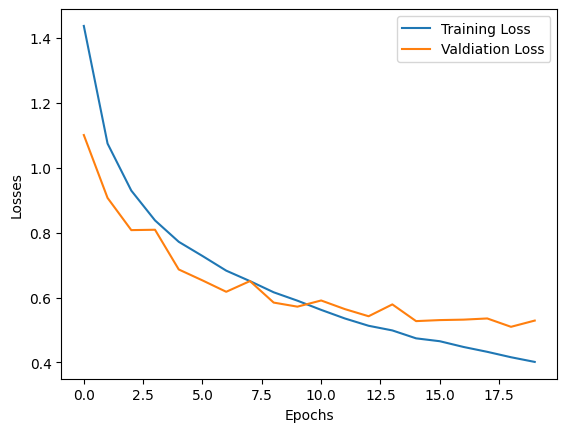

In [16]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Valdiation Loss": val_losses
})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Valdiation Loss"], label = "Valdiation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

plt.savefig("CIFAR10_train_val_plot.png", dpi=300, bbox_inches="tight") 

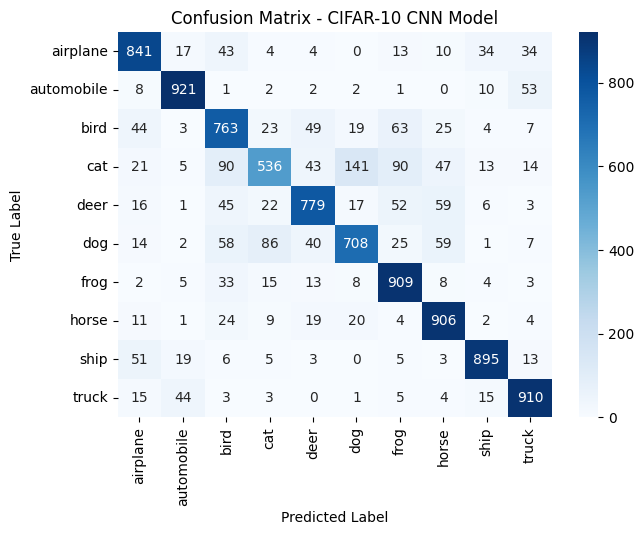

In [17]:
cm = confusion_matrix(all_actual, all_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - CIFAR-10 CNN Model")
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()